> Tensorflow Documentation - https://www.tensorflow.org/api_docs/python/

UV is An extremely fast Python package and project manager, faster 10-100x time than pip.
Installing UV, setting Up Virtual Environment and downloading depending dependencies.

```sh
pip install uv
uv venv
uv pip install -r requirements.txt
```

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd

# Linear Algebra

This notebook focuses particularly on methods for linear algebra present in the `linalg module`

In [6]:
x_1 = tf.constant([[1,2,0], [3,5,-1]])
x_2 = tf.constant([[1,0], [3,-1], [3,5]])
print(x_1.shape)
print(x_2.shape)
# Rule of matrix multiplication is m x n * n x p -> m x p

(2, 3)
(3, 2)


In [7]:
tf.linalg.matmul(
    # a, b, transpose_a=False, transpose_b=False, adjoint_a=False, adjoint_b=False, a_is_sparse=False, b_is_sparse=False, output_type=None, grad_a=False, grad_b=False, name=None
    x_1, x_2, transpose_a=False, transpose_b=False, adjoint_a=False, adjoint_b=False, a_is_sparse=False, b_is_sparse=False, output_type=None, grad_a=False, grad_b=False, name=None
)

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[  7,  -2],
       [ 15, -10]], dtype=int32)>

In [ ]:
# alternative
print(x_1@x_2) # @ is matrix multiplication operator

In [11]:
tf.transpose(x_1)

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[ 1,  3],
       [ 2,  5],
       [ 0, -1]], dtype=int32)>

- Set transpose_b = True to multiply a with transpose of b
- Similary, adjoint for adjoint of a matrix.
- _is_sparse is used to tell if the matrix is sparse ( most of the values is 0) so that tensorflow can skip the 0 calculations to achieve high optimization speed.

- Those arguments (grad_a and grad_b) are performance hints used internally by TensorFlow during the backward pass (backpropagation).

    - When you train a neural network, TensorFlow automatically calculates gradients (derivatives) to update the weights. To calculate the gradients of a matrix multiplication, it often has to do more matrix multiplications under the hood.

    - Here is what setting them to True does:

        - grad_a=True: Tells the underlying C++ code, "Hey, Tensor a isn't normal data, it's actually a gradient coming from backpropagation."
        - grad_b=True: Does the same for Tensor b.

    - Should you ever use them?
        - No. As a regular user building models, you should completely ignore them and leave them as False. TensorFlow's automatic differentiation system `tf.GradientTape()` will automatically set these flags to True behind the scenes when it calculates the backward pass for you.
        - Yes if step into advanced framework development.
            - Writing Custom Gradients : Sometimes standard backpropagation isn't what you want. If you invent a totally new mathematical layer or operation, you can use the `@tf.custom_gradient` decorator to manually write the math for the backward pass. 

In [13]:
tf.linalg.matmul(
    # Transpose_b = True
    x_1, x_1, transpose_a=False, transpose_b=True, adjoint_a=False, adjoint_b=False, a_is_sparse=False, b_is_sparse=False, output_type=None, grad_a=False, grad_b=False, name=None
)

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[ 5, 13],
       [13, 35]], dtype=int32)>

In [ ]:
print(x_1@tf.transpose(x_1)) # alternate

tf.Tensor(
[[ 5 13]
 [13 35]], shape=(2, 2), dtype=int32)


- tf.linalg.matrix_transpose - Transposes last two dimensions of tensor a.
- tf.linalg.adjoint - Transposes the last two dimensions of and conjugates tensor matrix.

In [15]:
# tf.linalg.band_part - Copy a tensor setting everything outside a central band in each innermost matrix to zero.

# Define the input tensor
input_tensor = tf.constant([
    [ 0,  1,  2,  3],
    [-1,  0,  1,  2],
    [-2, -1,  0,  1],
    [-3, -2, -1,  0]
])

In [16]:
# 1. Keep 1 lower diagonal, keep ALL upper diagonals (-1 means all)
tf.linalg.band_part(input_tensor, 1, -1).numpy()


array([[ 0,  1,  2,  3],
       [-1,  0,  1,  2],
       [ 0, -1,  0,  1],
       [ 0,  0, -1,  0]], dtype=int32)

In [17]:
# 2. Keep 2 lower diagonals, keep 1 upper diagonal
tf.linalg.band_part(input_tensor, 2, 1).numpy()

array([[ 0,  1,  0,  0],
       [-1,  0,  1,  0],
       [-2, -1,  0,  1],
       [ 0, -2, -1,  0]], dtype=int32)

In [18]:
# 3. Upper triangular: 0 lower diagonals, ALL upper diagonals
tf.linalg.band_part(input_tensor, 0, -1).numpy()

array([[0, 1, 2, 3],
       [0, 0, 1, 2],
       [0, 0, 0, 1],
       [0, 0, 0, 0]], dtype=int32)

In [19]:
# 4. Lower triangular: ALL lower diagonals, 0 upper diagonals
tf.linalg.band_part(input_tensor, -1, 0).numpy()

array([[ 0,  0,  0,  0],
       [-1,  0,  0,  0],
       [-2, -1,  0,  0],
       [-3, -2, -1,  0]], dtype=int32)

In [20]:
# 5. Diagonal: 0 lower diagonals, 0 upper diagonals
tf.linalg.band_part(input_tensor, 0, 0).numpy()

array([[0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0]], dtype=int32)

tf.linalg.cholesky - Computes the Cholesky decomposition of one or more square matrices.

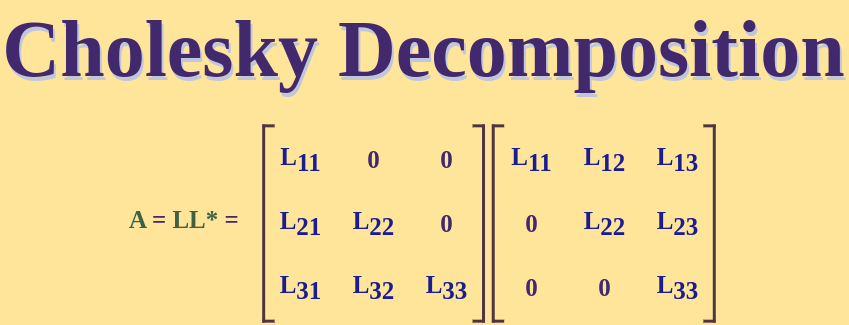

In [23]:
float_tensor = tf.constant([[4.0, 12.0],[12.0, 45.0]])
tf.linalg.cholesky(float_tensor)

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[2., 0.],
       [6., 3.]], dtype=float32)>

In [26]:
# cross - Compute the pairwise cross product.
a = tf.constant([[1, 2, 0], [3, 5, -1]])
b = tf.constant([[1, 0, 2], [-3, 2, -1]])
tf.linalg.cross(a,b)

<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
array([[ 4, -2, -2],
       [-3,  6, 21]], dtype=int32)>

In [30]:
# det - Computes the determinant of one or more square matrices.

square_mx = tf.constant([[1.0,0.0],[0.0,-1.0]])
tf.linalg.det(square_mx)

<tf.Tensor: shape=(), dtype=float32, numpy=-1.0>

In [32]:
# inv - Computes the inverse of one or more square invertible matrices or their adjoints (conjugate transposes).

sq_inv = tf.linalg.inv(square_mx)
print(sq_inv)

tf.Tensor(
[[ 1.  0.]
 [-0. -1.]], shape=(2, 2), dtype=float32)


In [33]:
#identity matrix
square_mx@sq_inv


<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[1., 0.],
       [0., 1.]], dtype=float32)>

- tf.linalg.svd - Computes the singular value decompositions of one or more matrices.
- s, u, v = svd(a) where
    - a is a tensor.
    - s is a tensor of singular values.
    - u is a tensor of left singular vectors.
    - v is a tensor of right singular vectors.


In [35]:
matrix = tf.constant([
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0],
    [7.0, 8.0, 9.0]
])
s, u, v = tf.linalg.svd(matrix)
print(s)
print()
print(u)
print()
print(v)

tf.Tensor([1.6848103e+01 1.0683696e+00 2.8763120e-07], shape=(3,), dtype=float32)

tf.Tensor(
[[ 0.21483716  0.8872305  -0.40824857]
 [ 0.5205872   0.24964423  0.8164965 ]
 [ 0.8263376  -0.3879429  -0.4082481 ]], shape=(3, 3), dtype=float32)

tf.Tensor(
[[ 0.47967106 -0.77669096  0.40824836]
 [ 0.5723676  -0.07568647 -0.81649655]
 [ 0.6650643   0.62531805  0.40824822]], shape=(3, 3), dtype=float32)


In [37]:
# trace - Compute the trace of a tensor x that is sum of diagnol values of each dimension
x = tf.constant([[[1, 2, 3],
                  [4, 5, 6],
                  [7, 8, 9]],
                 [[-1, -2, -3],
                  [-4, -5, -6],
                  [-7, -8, -9]]])
tf.linalg.trace(x)  # [15, -15]

<tf.Tensor: shape=(2,), dtype=int32, numpy=array([ 15, -15], dtype=int32)>

Einsum
- 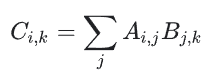 OR C[i,k] = sum_j A[i,j] * B[j,k]
- Equation - ij,jk->ik
- In short matrix multiplication but this equation can be modified to performed other operations



In [45]:
# Matrix Multiplication
A = np.array([
    [2, 6, 5, 2],
    [2, -2, 2, 3],
    [1, 5, 4, 0]
])

B = np.array([
    [2, 9, 0, 3, 0],
    [3, 6, 8, -2, 2],
    [1, 3, 5, 0, 1],
    [3, 0, 2, 0, 5]
])

print(A.shape)
print(B.shape)
np.einsum("ij,jk ->ik", A,B)

(3, 4)
(4, 5)


array([[33, 69, 77, -6, 27],
       [ 9, 12,  0, 10, 13],
       [21, 51, 60, -7, 14]])

In [46]:
# Hardmond Product - Each element gets multiplied with corresponding element -> A*B
A = np.array([
    [2, 6, 5, 2],
    [2, -2, 2, 3],
    [1, 5, 4, 0]
])

B = np.array([
    [2, 9, 0, 3],
    [3, 6,8, -2],
    [1, 3, 5, 0],
])

print(A.shape)
print(B.shape)
np.einsum("ij,ij ->ij", A,B)

(3, 4)
(3, 4)


array([[  4,  54,   0,   6],
       [  6, -12,  16,  -6],
       [  1,  15,  20,   0]])

In [ ]:
# Transpose => A.T

A = np.array([
    [2, 6, 5, 2],
    [2, -2, 2, 3],
    [1, 5, 4, 0]
])

np.einsum("ij -> ji", A)

array([[ 2,  2,  1],
       [ 6, -2,  5],
       [ 5,  2,  4],
       [ 2,  3,  0]])

batch size matrix multiplication

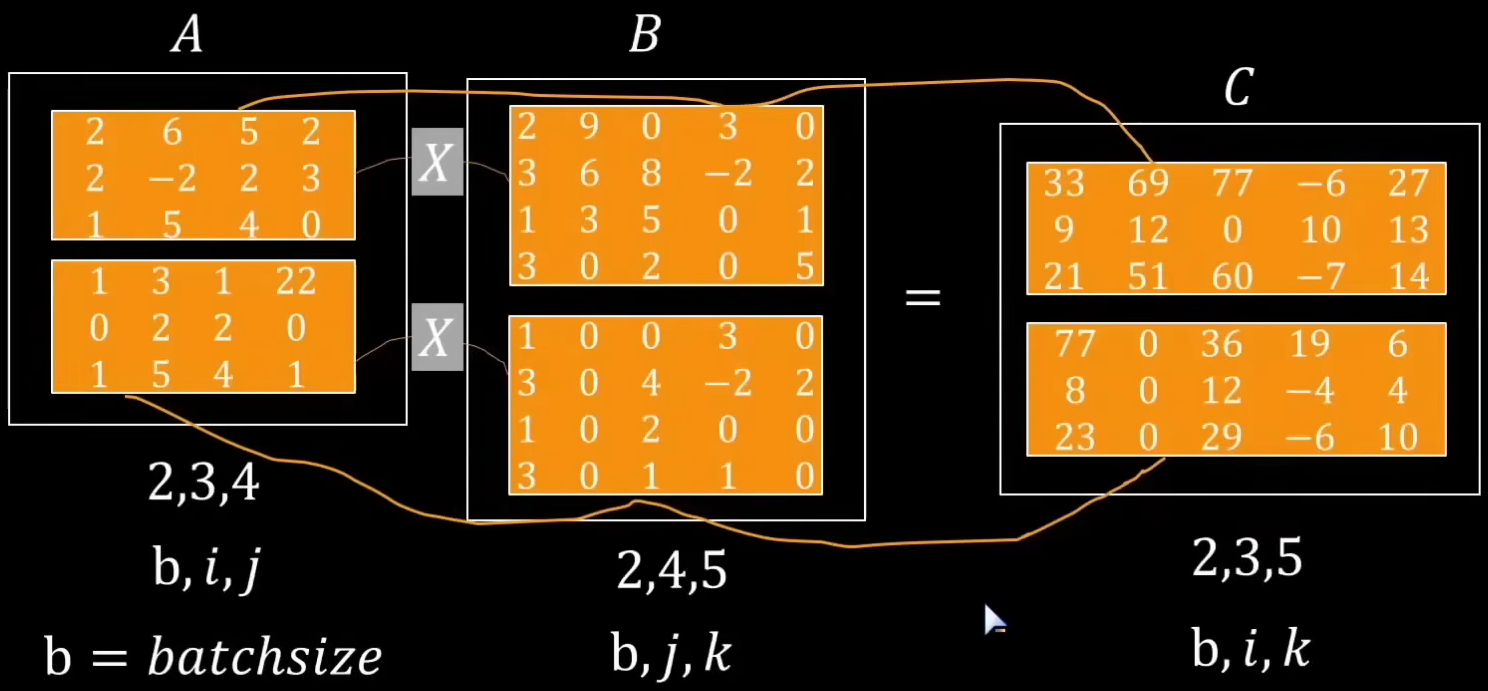

In [ ]:
#batch multiplication
A = np.array([
[[2, 6, 5, 2],
[2, -2, 2, 3],
[1, 5, 4, 0]],

[[1, 3, 1, 22],
[0, 2, 2, 0],
[1, 5, 4, 1]] ])

B = np.array([
[[2, 9, 0, 3, 0],
[3, 6, 8, -2, 2],
[1, 3, 5, 0, 1],
[3, 0, 2, 0, 5]],

[[1, 0, 0, 3, 0],
[3, 0, 4, -2, 2],
[1, 0, 2, 0, 0],
[3, 0, 1, 1, 0]] ])

print(A.shape, B.shape)

print("Batch Multiplication C : \n")
print(np.matmul(A,B),"\n")

print("Einsum C : \n")
print(np.einsum('bij,bjk -> bik', A,B))

(2, 3, 4) (2, 4, 5)
Batch Multiplication C : 

[[[33 69 77 -6 27]
  [ 9 12  0 10 13]
  [21 51 60 -7 14]]

 [[77  0 36 19  6]
  [ 8  0 12 -4  4]
  [23  0 29 -6 10]]] 

Einsum C : 

[[[33 69 77 -6 27]
  [ 9 12  0 10 13]
  [21 51 60 -7 14]]

 [[77  0 36 19  6]
  [ 8  0 12 -4  4]
  [23  0 29 -6 10]]]


In [52]:
# batch sum

print("Sum A : \n")
print(np.sum(A), "\n")

print("Einsum A : \n")
print(np.einsum('bij ->', A))

Sum A : 

72 

Einsum A : 

72


In [56]:
A = np.array([
    [2, 6, 5, 2],
    [2, -2, 2, 3],
    [1, 5, 4, 0]
])

print("Axis 0 Sum A: \n")
print(np.sum(A, axis=0),"\n")

print("Einsum A:" , "\n")
print(np.einsum('ij -> j', A))
print()

print("Axis 1 Sum A: \n")
print(np.sum(A, axis=1),"\n")

print("Einsum A: \n")
print(np.einsum('ij -> i', A))

Axis 0 Sum A: 

[ 5  9 11  5] 

Einsum A: 

[ 5  9 11  5]

Axis 1 Sum A: 

[15  5 10] 

Einsum A: 

[15  5 10]


Scaled Dot Product Attention
- From Research Paper "Attention is All You Need" by Google Researchers
- 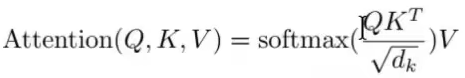

In [57]:
# Q = batchsize, s_q, modelsize
# K = batchsize, s_k, modelsize

Q = np.random.randn(32, 64, 512) #bqm
K = np.random.randn(32, 128, 512) #bkm

np.einsum("bqm,bkm -> bqk", Q,K)

array([[[ 9.30652376e-01, -3.90736285e+00,  4.43817926e+00, ...,
          8.98582251e+00,  8.12049937e+00,  8.47837553e+00],
        [ 2.92489123e+00, -8.27883550e+00,  1.53456534e+01, ...,
         -5.73897293e+00, -4.18979652e-01, -4.21529321e+01],
        [ 7.26820252e+00, -2.27720519e+01, -1.85157705e+01, ...,
          3.10678580e+01,  4.05245176e+01,  6.12851240e+00],
        ...,
        [ 1.77121222e+01,  1.53061004e+01,  3.23948917e+01, ...,
         -2.45401576e+01, -1.03279293e+01,  2.06701484e+01],
        [ 2.03868783e-01,  1.00437932e+01,  9.00024847e+00, ...,
         -1.94089772e+01, -8.92440922e+00, -6.11676050e+00],
        [-4.29306622e+01, -1.84849485e+01,  2.75571374e+01, ...,
          7.32198233e-01, -1.19566063e+01, -4.35517447e+01]],

       [[-4.22956807e+01,  9.75205305e+00,  2.17555301e+01, ...,
         -1.31787161e+01, -2.54571688e+01,  4.56771955e+01],
        [-4.23124857e+01, -3.39936549e+01,  3.80288320e+00, ...,
         -1.50665720e+01,  3.63536497e

Scaled Dot Product Attention
- From Research Paper "Reformer: The Efficient Transformer" by Google Researchers
- 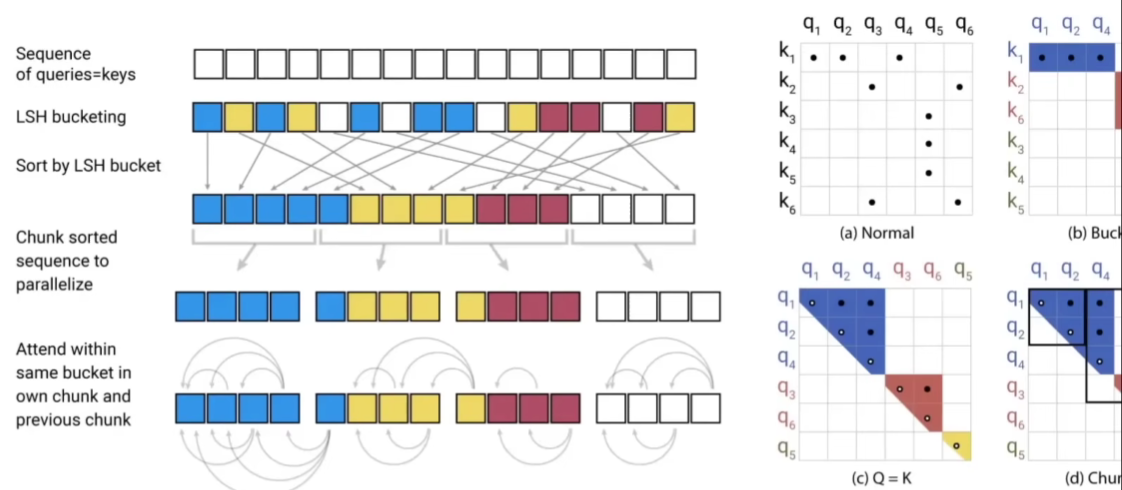
- 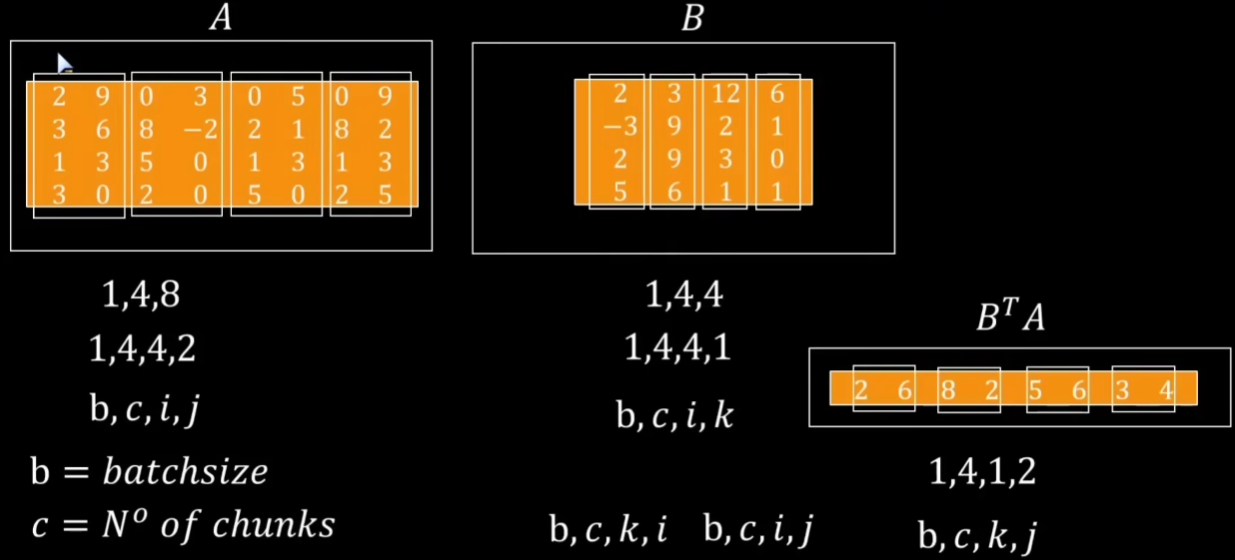
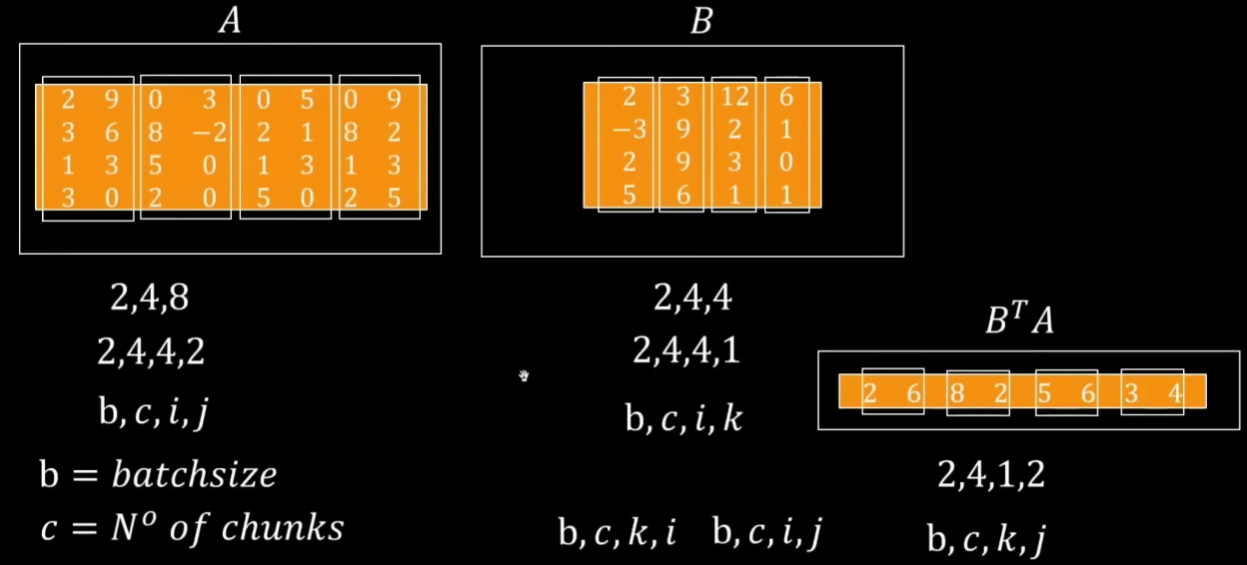

In [ ]:
A = np.random.randn(2, 4, 4, 2)# bcij
B = np.random.randn(2, 4, 4, 1)# bcik

np.einsum("bcik,bcij -> bckj", B, A)
# np.matmul(np.transpose(B, (0,1,3,2)), A)

array([[[[-3.32391904,  1.54099197]],

        [[ 0.35981594,  3.09131671]],

        [[ 0.22426442, -0.02216345]],

        [[ 0.81877756, -0.21549343]]],


       [[[ 0.25973586, -0.18423506]],

        [[-0.42601005,  0.06855315]],

        [[-2.17997786,  1.94134573]],

        [[-6.81961115,  1.06066788]]]])